In [2]:
import scanpy as sc
import pandas as pd
from scipy.sparse import csr_matrix

In [5]:
print("1. Loading the massive matrix... (Your M4 will chew through this quickly)")
# The .T is critical! R stores data as (Genes x Cells). Python needs it as (Cells x Genes).
adata = sc.read_mtx("/Users/christianlangridge/Desktop/SMT-Pipeline/data/Model/Matrix bundle/matrix.mtx").T 

# Convert to a Compressed Sparse Row (CSR) matrix. 
# This makes future operations (like UMAPs and filtering) lightning fast.
adata.X = csr_matrix(adata.X)


1. Loading the massive matrix... (Your M4 will chew through this quickly)


In [9]:

print("2. Loading labels and metadata...")
# Use sep='\t' since we saved them as .tsv (tab-separated) in Kaggle
genes = pd.read_csv("/Users/christianlangridge/Desktop/SMT-Pipeline/data/Model/Matrix bundle/genes.tsv", header=None, sep='\t')
barcodes = pd.read_csv("/Users/christianlangridge/Desktop/SMT-Pipeline/data/Model/Matrix bundle/barcodes.tsv", header=None, sep='\t')
metadata = pd.read_csv("/Users/christianlangridge/Desktop/SMT-Pipeline/data/Model/Matrix bundle/metadata.csv", index_col=0)

print("3. Stitching it all together...")
# Assign the labels to the AnnData object
adata.var_names = genes[0].values
adata.obs_names = barcodes[0].values
adata.obs = metadata


2. Loading labels and metadata...
3. Stitching it all together...


In [ ]:
### SAVING STICHED H5AD OBJECT 

print("4. Saving your Master File...")
# Save it as a compressed HDF5 file. This is your new gold standard.
adata.write("neurectoderm_complete.h5ad", compression="gzip")

print("-" * 30)
print("✅ STITCHING COMPLETE!")
print(f"Total Cells: {adata.n_obs}")
print(f"Total Genes: {adata.n_vars}")
print("Your data is ready for analysis!")

In [11]:
adata = sc.read_h5ad("/Users/christianlangridge/Desktop/SMT-Pipeline/data/Model/AnnData object/neurectoderm_complete.h5ad")

In [12]:
print(adata)

AnnData object with n_obs × n_vars = 41059 × 24264
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'dataset', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'RNA_snn_res.1', 'seurat_clusters', 'RNA_snn_res.0.6', 'cluster.ids', 'class3'


In [ ]:
# A quick standard pipeline to generate a UMAP in Python:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

# Convert the cluster column from numbers to categories
adata.obs['seurat_clusters'] = adata.obs['seurat_clusters'].astype('category')



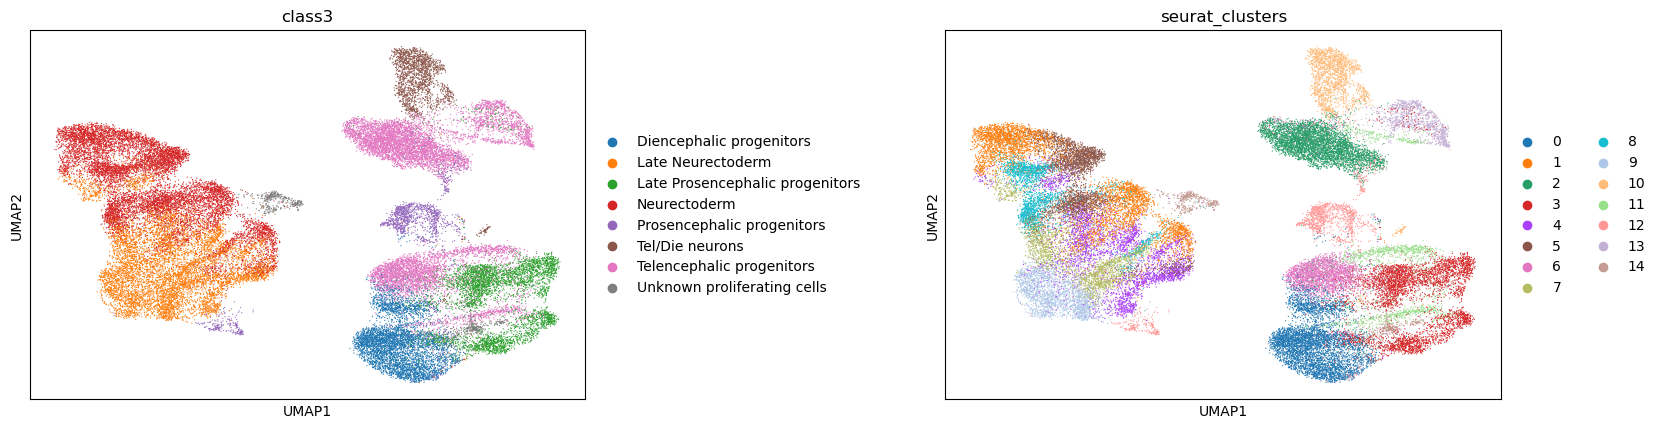

In [9]:
# Now you can plot it using the metadata columns we saved!
sc.pl.umap(adata, color=['class3', 'seurat_clusters'], wspace=0.5)

In [3]:
GLS_ko_AnnData = sc.read_h5ad("/Users/christianlangridge/Desktop/SMT-Pipeline/data/Fleck et al/RNA_data.h5ad")

In [4]:
print(GLS_ko_AnnData)

AnnData object with n_obs × n_vars = 49718 × 33538
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent_mito', 'RNA_snn_res.0.8', 'seurat_clusters', 'organoid', 'line', 'p_singlet', 'age', 'nowakowski_prediction', 'RNA_snn_res.1', 'glyc_cluster'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'


In [8]:
print(GLS_ko_AnnData.obs.columns.tolist())

['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent_mito', 'RNA_snn_res.0.8', 'seurat_clusters', 'organoid', 'line', 'p_singlet', 'age', 'nowakowski_prediction', 'RNA_snn_res.1', 'glyc_cluster']


In [10]:
GLS_ko_AnnData.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,percent_mito,RNA_snn_res.0.8,seurat_clusters,organoid,line,p_singlet,age,nowakowski_prediction,RNA_snn_res.1,glyc_cluster
RNA_DAY11_SJ_AAACCCAAGTCGTTAC-1,RNA_DAY11_SJ,13722.0,4238,0.040154,3,8,DAY11_H9,H9,1.0,11.0,IPC,8,0
RNA_DAY11_SJ_AAACCCAGTAGCGAGT-1,RNA_DAY11_SJ,34067.0,6444,0.094226,3,16,DAY11_Wibj2,Wibj2,1.0,11.0,IPC,16,0
RNA_DAY11_SJ_AAACCCAGTGACTGAG-1,RNA_DAY11_SJ,31958.0,6389,0.051067,3,19,DAY11_Wibj2,Wibj2,1.0,11.0,IPC,19,0
RNA_DAY11_SJ_AAACGAAAGAAGCCAC-1,RNA_DAY11_SJ,22512.0,5511,0.063699,3,8,DAY11_H9,H9,1.0,11.0,RG,8,0
RNA_DAY11_SJ_AAACGAATCTGCTGAA-1,RNA_DAY11_SJ,23513.0,5486,0.074895,3,8,DAY11_Wibj2,Wibj2,1.0,11.0,IPC,8,0


In [5]:
# A quick standard pipeline to generate a UMAP in Python:
sc.pp.normalize_total(GLS_ko_AnnData, target_sum=1e4)
sc.pp.log1p(GLS_ko_AnnData)
sc.pp.highly_variable_genes(GLS_ko_AnnData, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.tl.pca(GLS_ko_AnnData, svd_solver='arpack')
sc.pp.neighbors(GLS_ko_AnnData, n_neighbors=10, n_pcs=40)
sc.tl.umap(GLS_ko_AnnData)

# Convert the cluster column from numbers to categories
GLS_ko_AnnData.obs['seurat_clusters'] = GLS_ko_AnnData.obs['seurat_clusters'].astype('category')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
# Now you can plot it using the metadata columns we saved!
sc.pl.umap(GLS_ko_AnnData, color=['class3', 'seurat_clusters'], wspace=0.5)

KeyError: 'class3'

<Figure size 1920x480 with 0 Axes>